The **Llama-8B model** can need

#####  with fp-32:
- 32 GB for the model `parameters` (8B * 4 Bytes = 32 GB)
- 32 GB for the model `Gradients` (8B * 4 Bytes = 32 GB)
- 64 GB for the `optimizer  states` (8B *  2 * 4 Bytes) = 64 GB

`around 128 GB in total` This cannot fit on one GPU.

#####  with fp-16:
- 16 GB for the model `parameters` (8B * 2 Bytes = 16 GB)
- 16 GB for the model `Gradients` (8B * 2 Bytes = 16 GB)
- 32 GB for the `optimizer states`.(8B *  2 * 2 Bytes) = 32 GB

`around 64 GB in total`

Half-precision
Quantization
Gradient accumulation (many GPUs)


Llama takes three inputs:

- Tokens
- Attention mask
- Positional Embedding

Evaluation Metrics:
- Perplexity
- BLEU, ROUGE

##### Import Libraries

In [3]:
# ShoW each Cell's Execution Time
# %pip install ipython-autotime  datasets boto3 python-dotenv bitsandbytes
# %pip install --upgrade transformers

%pip install -U ipython-autotime bitsandbytes
%load_ext autotime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 MB 11.3 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.
time: 325 µs (started: 2024-08-23 10:13:08 +00:00)


In [4]:
import torch
if torch.cuda.is_available():
    DEVICE = torch.device('cuda:0')
    print(f" DEVICE: {DEVICE}. GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    DEVICE = 'cpu'
    print(f" DEVICE: {DEVICE}. No GPU available. Training will run on CPU.")

 DEVICE: cuda:0. GPU: Tesla T4 is available.
time: 2.97 s (started: 2024-08-23 10:13:08 +00:00)


In [5]:
import numpy as np
import torch
import torch.nn as nn
from torch.optim import AdamW
import torch.nn.functional as F

from transformers import  AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, get_linear_schedule_with_warmup 
from torch.utils.data import DataLoader, Dataset, RandomSampler
from datasets import load_dataset
from torch.utils.data import Subset, Dataset
from torch.nn.utils.rnn import pad_sequence
# from torch.cuda.amp import GradScaler, autocast
from torch.amp import GradScaler, autocast


# import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import re
import os
from functools import partial
import boto3

import warnings
import logging
import sys
# import json
from dotenv import load_dotenv

## Local Vscode
# load_dotenv()
# HF_TOKEN = os.getenv('TF_TOKEN')

## Colab
# from google.colab import userdata
# HF_TOKEN= userdata.get('HF_TOKEN')

## kaggle
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
HF_TOKEN = user_secrets.get_secret("HF_TOKEN")

time: 2.24 s (started: 2024-08-23 10:13:11 +00:00)


In [6]:
warnings.filterwarnings("ignore", category=FutureWarning, module="huggingface_hub.file_download")
logging.getLogger("transformers").setLevel(logging.ERROR)


time: 779 µs (started: 2024-08-23 10:13:13 +00:00)


In [7]:
#for local vscode
# sys.path.append('./src') #link to GTL libraries 
# import src.guided_transfer_learning as gtl


time: 5.79 ms (started: 2024-08-23 10:13:13 +00:00)


##### Functions:

In [8]:
plt.style.use('dark_background')

time: 2.11 ms (started: 2024-08-23 10:13:13 +00:00)


In [9]:
def download_from_s3(bucket_name, s3_file_path, local_file_path):
    s3 = boto3.client('s3')
    s3.download_file(bucket_name, s3_file_path, local_file_path)
    print(f'File s3://{bucket_name}/{s3_file_path} downloaded to {local_file_path}')

def upload_to_s3(local_file_path, bucket_name, s3_file_path):
    s3 = boto3.client('s3')
    s3.upload_file(local_file_path, bucket_name, s3_file_path)
    print(f'File {local_file_path} uploaded to s3://{bucket_name}/{s3_file_path}')


time: 1.47 ms (started: 2024-08-23 10:13:13 +00:00)


In [10]:
def plot_multiple_results(results_list, title="Train and Validation Results (Accuracy and Loss)",legend_fontsize=9, nb_epochs_toplot=None):
    fig, axs = plt.subplots(1, 2, figsize=(40, 10))
    styles = [{'linestyle': (0,(1,1)), 'marker': 'o', 'color': '#2ca02c'},{'linestyle': 'dashdot', 'marker': 'x', 'color': '#1f77b4'},
        {'linestyle': (0,(5,1)), 'marker': 's', 'color': '#d62728'},{'linestyle': (5,(10,3)), 'marker': 'd', 'color': '#ff7f0e'} ]
    for i, results in enumerate(results_list):
        train_loss, train_acc = results['train_results']
        val_loss, val_acc = results['validation_results']
        if nb_epochs_toplot is None:
            max_epochs = max(max(len(train_acc) for results in results_list),max(len(val_acc) for results in results_list),max(len(train_loss) for results in results_list),max(len(val_loss) for results in results_list))
        else:
            max_epochs = nb_epochs_toplot
        train_loss , train_acc , val_loss, val_acc = train_loss[:max_epochs], train_acc[:max_epochs], val_loss[:max_epochs+1], val_acc[:max_epochs+1],
        style = styles[i % len(styles)]
        # Plot the training and validation accuracy
        axs[0].plot(range(1,len(train_acc) + 1), train_acc, marker=style['marker'], markersize=3, color=style['color'], label=f'Training Accuracy Selection {i+1}')
        axs[0].plot(val_acc, linestyle=style['linestyle'], marker=style['marker'],  markersize=3, color=style['color'], label=f'Validation Accuracy Selection {i+1}')
        # Plot the training and validation loss
        axs[1].plot(range(1,len(train_loss) + 1), train_loss, marker=style['marker'], markersize=3,color=style['color'], label=f'Training Loss Selection {i+1}')
        axs[1].plot(val_loss, linestyle=style['linestyle'], marker=style['marker'], markersize=3,color=style['color'], label=f'Validation Loss Selection {i+1}')
    for ax in axs:
        ax.set_xticks(range(0, max_epochs + 1, 2))
    # Set labels and titles
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].legend(fontsize=legend_fontsize)
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend(fontsize=legend_fontsize)
    fig.suptitle(title)
    plt.show()


time: 2.66 ms (started: 2024-08-23 10:13:13 +00:00)


In [11]:
# Iterate over all parameters in the model
def check_trainable_layers(model):
    for name, param in model.named_parameters():
        if param.requires_grad:
            print(f"{name} is || TRAINABLE || ")
        else:
            print(f"{name} is || NOT TRAINABLE || ")
# Iterate over all parameters in the model

def list_model_layers(model):
    for name, param in model.named_parameters():
        print(f"{name}")

def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def unfreeze_BERT_layers(bert, nb_layer_to_unfreeze):
    if (0 < nb_layer_to_unfreeze <= len(bert.encoder.layer)):
        for layer in bert.encoder.layer[-nb_layer_to_unfreeze:]:
            for param in layer.parameters():
                param.requires_grad = True
        for layer in bert.encoder.layer[:len(bert.encoder.layer) - nb_layer_to_unfreeze]:
            for param in layer.parameters():
                param.requires_grad = False
    else:
        print(" Number of unfreeze layers is larger than number of layers or less than 1.")

def unfreeze_all_Llama_layers(model ):
    for param in model.parameters():
        param.requires_grad = True

time: 1.99 ms (started: 2024-08-23 10:13:13 +00:00)


In [12]:
# Iterate over all parameters in the model
def count_trainable_layers(model):
    trainable_layers = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_layers += 1
    return trainable_layers

def count_parameters(model):
    print("Number of parameters:", sum(p.numel() for p in model.parameters()))

def plot_results(results, title="Train and Validation Loss"):
    train_loss = results['train_results'][0]
    val_loss = results['validation_results'][0]
    fig, axs = plt.subplots(figsize=(8, 3))
    # Plot the training and validation loss
    axs.plot(range(1,len(train_loss)+1),train_loss, label='Training Loss')
    axs.plot(val_loss, label='Validation Loss')
    axs.set_xlabel('Epoch')
    axs.set_ylabel('Loss')
    axs.set_title(title)
    axs.legend()
    plt.show()

def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]

time: 2.3 ms (started: 2024-08-23 10:13:13 +00:00)


##### Simple Llama from Scratch

In [13]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim):
        super(TransformerBlock, self).__init__()
        self.attention = nn.MultiheadAttention(embed_dim, num_heads)
        self.feed_forward = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.ReLU(),
            nn.Linear(ff_hidden_dim, embed_dim)
        )
        self.layer_norm1 = nn.LayerNorm(embed_dim)
        self.layer_norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        # Attention
        attn_output, _ = self.attention(x, x, x)
        x = self.layer_norm1(x + attn_output)
        # Feed-forward
        ff_output = self.feed_forward(x)
        x = self.layer_norm2(x + ff_output)
        return x

class SimpleLlama(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim,pad_token_id=0):
        super(SimpleLlama, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim) 
        self.transformer_blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_hidden_dim) for _ in range(num_layers)
        ]) 
        self.fc_out = nn.Linear(embed_dim, vocab_size)
        self.embed_dim = embed_dim
        self.loss_fn = nn.CrossEntropyLoss(ignore_index=pad_token_id)

    def forward(self, input_ids, attention_mask=None, labels=None):
        # Embedding
        x = self.embedding(input_ids)
        x = x.transpose(0, 1)  # Sequence-first for PyTorch Transformer
        
        # Attention mask handling
        if attention_mask is not None:
            # Convert attention mask to the format expected by PyTorch Transformer
            # PyTorch's MultiheadAttention expects a mask of shape (seq_len, seq_len)
            attention_mask = attention_mask.unsqueeze(1).expand(-1, input_ids.size(1), -1)
            attention_mask = attention_mask.float().masked_fill(attention_mask == 0, float('-inf'))

        # Pass through transformer blocks
        for block in self.transformer_blocks:
            x = block(x)
        x = x.transpose(0, 1)  # Batch-first

        # Output logits
        logits = self.fc_out(x)
        
        outputs = {"logits": logits}
        
        if labels is None:
            outputs['loss'] = None
        else:
            # Shift labels right by one position
            labels = labels[:, 1:].contiguous()
            logits = logits[:, :-1, :].contiguous()
            loss = self.loss_fn(logits.view(-1, logits.size(-1)), labels.view(-1))
            outputs["loss"] = loss
        return outputs
    

    def generate(self,input_ids, max_length, temperature=1.0, end_token_id=None):
        self.eval()  # Set the model to evaluation mode
        
        with torch.no_grad():
            for _ in range(max_length - len(input_ids)):
                # Forward pass
                outputs = self(input_ids)
                next_token_logits = outputs["logits"][:, -1, :]
                
                # Apply temperature
                next_token_logits = next_token_logits / temperature
                
                # Sample from the filtered distribution
                probs = F.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
                
                # Append the new token to the input sequence
                input_ids = torch.cat([input_ids, next_token], dim=-1)
                
                # Check if we've generated an end-of-sequence token
                if next_token.item() == '<|end_of_sentence|>':
                    break
                if end_token_id is not None and next_token.item() == end_token_id:
                    break
        
        return input_ids


time: 3.52 ms (started: 2024-08-23 10:13:13 +00:00)


In [14]:
# Load the tokenizer 
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token


tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

time: 1.23 s (started: 2024-08-23 10:13:13 +00:00)


In [15]:
### Sample sentence
# sentence = "This is a test sentence for LLaMA."
# # Tokenize the input sentence
# tokenized_input = llama3_tokenizer(sentence, return_tensors='pt')
# print(tokenized_input)
# # Extract input_ids and attention_mask
# input_ids = tokenized_input['input_ids'].to(DEVICE)
# attention_mask = tokenized_input['attention_mask'].to(DEVICE)
# print(input_ids)
# print(attention_mask)
# # Tokenize the input sentence
# tokenized_input = llama3_tokenizer(sentence, max_length=8, padding='max_length', truncation=True, return_tensors='pt')
# print(tokenized_input) 
# print(llama3_tokenizer.vocab_size)
# print(len(llama3_tokenizer)) 

time: 691 µs (started: 2024-08-23 10:13:14 +00:00)


In [16]:
## LLama-3 Model Arguments:

dim: int = 4096
n_layers: int = 32
n_heads: int = 32
# n_kv_heads: Optional[int] = None 
vocab_size: int = -1
multiple_of: int = 256  # make SwiGLU hidden layer size multiple of large power of 2
# ffn_dim_multiplier: Optional[float] = None
norm_eps: float = 1e-5
rope_theta: float = 500000

max_batch_size: int = 32
max_seq_len: int = 2048

time: 6.5 ms (started: 2024-08-23 10:13:14 +00:00)


In [17]:
len(llama3_tokenizer)

128256

time: 20.3 ms (started: 2024-08-23 10:13:14 +00:00)


In [18]:
# Example usage
vocab_size = len(llama3_tokenizer)     #128256  
embed_dim = 1         #4096   # Example embedding dimension
num_heads = 1         #32     # Number of attention heads
num_layers = 1        #32     # Number of transformer layers
ff_hidden_dim = 1     #4096   # Feed-forward hidden dimension

simple_llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)


time: 189 ms (started: 2024-08-23 10:13:14 +00:00)


In [19]:
sentence = "This is a test sentence for LLaMA."
# Tokenize the input sentence
tokenized_input = llama3_tokenizer(sentence, return_tensors='pt').to(DEVICE)
output_tokens = simple_llama3_model.generate(tokenized_input['input_ids'], max_length=32)
llama3_tokenizer.decode(output_tokens[0])

'<|begin_of_text|>This is a test sentence for LLaMA. tighten bei اگرClients턴 sits Ấn남도 aster رجicits accountIdGOOD ıs userInfo(Throwableухistratorneedle mejor Mercury dreamsOTOR pornost�PLACE GMlol■■:%<|reserved_special_token_41|>'

time: 532 ms (started: 2024-08-23 10:13:15 +00:00)


In [20]:
sentence = "This is a test sentence for LLaMA."
# Tokenize the input sentence
tokenized_input = llama3_tokenizer(sentence, return_tensors='pt').to(DEVICE)
output_tokens = simple_llama3_model(tokenized_input['input_ids'],
                                    attention_mask=tokenized_input['attention_mask'],
                                    labels=tokenized_input['input_ids'])
output_tokens

{'logits': tensor([[[-0.6124,  0.9550,  0.0780,  ...,  0.3921, -0.0216, -0.0239],
          [-0.6124,  0.9550,  0.0780,  ...,  0.3921, -0.0216, -0.0239],
          [-0.6124,  0.9550,  0.0780,  ...,  0.3921, -0.0216, -0.0239],
          ...,
          [-0.6124,  0.9550,  0.0780,  ...,  0.3921, -0.0216, -0.0239],
          [-0.6124,  0.9550,  0.0780,  ...,  0.3921, -0.0216, -0.0239],
          [-0.6124,  0.9550,  0.0780,  ...,  0.3921, -0.0216, -0.0239]]],
        device='cuda:0', grad_fn=<ViewBackward0>),
 'loss': tensor(11.9474, device='cuda:0', grad_fn=<NllLossBackward0>)}

time: 116 ms (started: 2024-08-23 10:13:15 +00:00)


In [21]:
# Total number of parameters
total_params = sum(p.numel() for p in simple_llama3_model.parameters())
print(f"Total number of parameters: {total_params}")


Total number of parameters: 384784
time: 707 µs (started: 2024-08-23 10:13:15 +00:00)


##### Llama-3 from Hugging Face with Quantization

In [22]:
# %pip install -U bitsandbytes

time: 3.22 ms (started: 2024-08-23 10:13:15 +00:00)


In [40]:
bnb_config = BitsAndBytesConfig( 
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,  # or use bfloat16 if your hardware supports it
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4", #4bit Normal Float
#     bnb_4bit_compute_dtype=torch.bfloat16
        )

time: 2.39 ms (started: 2024-08-23 10:20:34 +00:00)


In [41]:
# Load the tokenizer and model
model_name = "meta-llama/Meta-Llama-3.1-8B"
llama3_tokenizer = AutoTokenizer.from_pretrained(model_name,token=HF_TOKEN)
llama3_tokenizer.pad_token = llama3_tokenizer.eos_token

time: 424 ms (started: 2024-08-23 10:20:35 +00:00)


In [42]:
# del llama3_model
torch.cuda.empty_cache()

time: 389 µs (started: 2024-08-23 10:20:36 +00:00)


In [44]:
torch.cuda.empty_cache()

# del llama3_mod

time: 457 µs (started: 2024-08-23 10:20:40 +00:00)


In [91]:
def get_cuda_summary():
    print(torch.cuda.memory_summary())
get_cuda_summary

<function __main__.get_cuda_summary()>

time: 3.46 ms (started: 2024-08-23 11:41:08 +00:00)


In [46]:
llama3_model = AutoModelForCausalLM.from_pretrained(model_name, 
                                                    device_map="auto",
                                                    quantization_config=bnb_config,
                                                    token=HF_TOKEN)


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `load_in_8bit_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

time: 592 ms (started: 2024-08-23 10:20:47 +00:00)


In [24]:
#  Checking the data type of each layer's parameters
for name, param in llama3_model.named_parameters():
    print(f"Layer: {name} | Data Type: {param.dtype}")

Layer: model.embed_tokens.weight | Data Type: torch.float32
Layer: model.layers.0.self_attn.q_proj.weight | Data Type: torch.float32
Layer: model.layers.0.self_attn.k_proj.weight | Data Type: torch.float32
Layer: model.layers.0.self_attn.v_proj.weight | Data Type: torch.float32
Layer: model.layers.0.self_attn.o_proj.weight | Data Type: torch.float32
Layer: model.layers.0.mlp.gate_proj.weight | Data Type: torch.float32
Layer: model.layers.0.mlp.up_proj.weight | Data Type: torch.float32
Layer: model.layers.0.mlp.down_proj.weight | Data Type: torch.float32
Layer: model.layers.0.input_layernorm.weight | Data Type: torch.float32
Layer: model.layers.0.post_attention_layernorm.weight | Data Type: torch.float32
Layer: model.layers.1.self_attn.q_proj.weight | Data Type: torch.float32
Layer: model.layers.1.self_attn.k_proj.weight | Data Type: torch.float32
Layer: model.layers.1.self_attn.v_proj.weight | Data Type: torch.float32
Layer: model.layers.1.self_attn.o_proj.weight | Data Type: torch.flo

In [25]:
check_trainable_layers(llama3_model) 

model.embed_tokens.weight is || TRAINABLE || 
model.layers.0.self_attn.q_proj.weight is || TRAINABLE || 
model.layers.0.self_attn.k_proj.weight is || TRAINABLE || 
model.layers.0.self_attn.v_proj.weight is || TRAINABLE || 
model.layers.0.self_attn.o_proj.weight is || TRAINABLE || 
model.layers.0.mlp.gate_proj.weight is || TRAINABLE || 
model.layers.0.mlp.up_proj.weight is || TRAINABLE || 
model.layers.0.mlp.down_proj.weight is || TRAINABLE || 
model.layers.0.input_layernorm.weight is || TRAINABLE || 
model.layers.0.post_attention_layernorm.weight is || TRAINABLE || 
model.layers.1.self_attn.q_proj.weight is || TRAINABLE || 
model.layers.1.self_attn.k_proj.weight is || TRAINABLE || 
model.layers.1.self_attn.v_proj.weight is || TRAINABLE || 
model.layers.1.self_attn.o_proj.weight is || TRAINABLE || 
model.layers.1.mlp.gate_proj.weight is || TRAINABLE || 
model.layers.1.mlp.up_proj.weight is || TRAINABLE || 
model.layers.1.mlp.down_proj.weight is || TRAINABLE || 
model.layers.1.input_laye

In [113]:
def print_model_layers(module, prefix=''):
    for name, child in module.named_children():
        full_name = f"{prefix}.{name}" if prefix else name
        print(full_name)
        print_model_layers(child, full_name)

# Print all layers of the model
# print_model_layers(llama3_model)

time: 708 µs (started: 2024-08-23 08:05:56 +00:00)


In [26]:
# Unfreeze model layers:
for param in llama3_model.parameters():
    if param.dtype in [torch.float32, torch.float64, torch.float16, torch.bfloat16]:
        param.requires_grad = True
    else:
        param.requires_grad = False

time: 2.85 ms (started: 2024-08-23 10:16:11 +00:00)


In [27]:
check_trainable_layers(llama3_model)

model.embed_tokens.weight is || TRAINABLE || 
model.layers.0.self_attn.q_proj.weight is || TRAINABLE || 
model.layers.0.self_attn.k_proj.weight is || TRAINABLE || 
model.layers.0.self_attn.v_proj.weight is || TRAINABLE || 
model.layers.0.self_attn.o_proj.weight is || TRAINABLE || 
model.layers.0.mlp.gate_proj.weight is || TRAINABLE || 
model.layers.0.mlp.up_proj.weight is || TRAINABLE || 
model.layers.0.mlp.down_proj.weight is || TRAINABLE || 
model.layers.0.input_layernorm.weight is || TRAINABLE || 
model.layers.0.post_attention_layernorm.weight is || TRAINABLE || 
model.layers.1.self_attn.q_proj.weight is || TRAINABLE || 
model.layers.1.self_attn.k_proj.weight is || TRAINABLE || 
model.layers.1.self_attn.v_proj.weight is || TRAINABLE || 
model.layers.1.self_attn.o_proj.weight is || TRAINABLE || 
model.layers.1.mlp.gate_proj.weight is || TRAINABLE || 
model.layers.1.mlp.up_proj.weight is || TRAINABLE || 
model.layers.1.mlp.down_proj.weight is || TRAINABLE || 
model.layers.1.input_laye

In [ ]:
#### Testing the model

test_text = "What is LLama-3?? "
tokenized_text = llama3_tokenizer(test_text, return_tensors="pt")
print(tokenized_text)

completion = llama3_model(tokenized_text['input_ids'],
                          tokenized_text['attention_mask'],
                          labels = tokenized_text['input_ids']
                          )
print(completion)


In [97]:
for name, param in llama3_model.named_parameters():
    if param.dtype in [torch.float16, torch.float32, torch.float64]:  # Check for floating point types
        print(f"{name}: Mean = {param.mean()}, Std = {param.std()}")
    else: 
        print(f"{name}: Non-floating point tensor of type {param.dtype}, skipping mean and std computation. =============================")


model.embed_tokens.weight: Mean = 2.282857894897461e-05, Std = 0.01061248779296875
model.layers.0.self_attn.q_proj.weight: Non-floating point tensor of type torch.uint8, skipping mean and std computation. =============================
model.layers.0.self_attn.k_proj.weight: Non-floating point tensor of type torch.uint8, skipping mean and std computation. =============================
model.layers.0.self_attn.v_proj.weight: Non-floating point tensor of type torch.uint8, skipping mean and std computation. =============================
model.layers.0.self_attn.o_proj.weight: Non-floating point tensor of type torch.uint8, skipping mean and std computation. =============================
model.layers.0.mlp.gate_proj.weight: Non-floating point tensor of type torch.uint8, skipping mean and std computation. =============================
model.layers.0.mlp.up_proj.weight: Non-floating point tensor of type torch.uint8, skipping mean and std computation. =============================
model.layers.

In [ ]:
completion = llama3_model.generate(input_ids=tokenized_text['input_ids'],
                                   attention_mask=tokenized_text['attention_mask'],
                                   )

In [ ]:
llama3_tokenizer.decode(completion[0])

In [66]:
# Check GPU memory allocated and cached
print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"Cached memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")


Allocated memory: 7.98 GB
Cached memory: 8.38 GB
time: 2.98 ms (started: 2024-08-23 06:06:01 +00:00)


##### Train and Evaluate Functions

In [59]:

# Define the training function
def train_model(model, optimizer, epochs, train_loader, validation_loader, with_early_stopping=True, train_loader_sampler=None, validation_loader_sampler=None, train_verbose=True, eval_verbose=True, with_GTL=False, guidance_matrix=None, with_autocast=True,patience=3, with_lr_sceduler=False, time_to_sleep=15):
    best_val_loss = float('inf')
    epochs_without_improvement = 0
    skip = 2000 if epochs > 10000 else 300 if epochs > 1000 else 30 if epochs > 100 else 5 if epochs > 10 else 1
    model.train()
    train_loss_vals = [];  val_loss_vals = [];

    num_training_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=num_training_steps) if with_lr_sceduler  else None

    grad_scaler = GradScaler('cuda') if with_autocast else None

    print(f"# Epoch: 0  (Before start training) ")
    val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=eval_verbose)
    val_loss_vals.append(val_loss)
    print("================================================================================================")
    for epoch in range(epochs):
        epoch_loss = 0.0; epoch_loss_sum = 0.0; 
        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f"# Epoch: {epoch+1} (Learning rate: {optimizer.param_groups[0]['lr']}) ", end='')
            
        for batch in train_loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)

            # Use autocast for mixed precision training
            if with_autocast:
                with autocast('cuda'):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                    loss = outputs['loss']
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']
            
            model.zero_grad()

            if with_autocast:
                grad_scaler.scale(loss).backward() ## Scales the loss and computes gradients
                if with_GTL and guidance_matrix is None:
                    print('Guidance matrix is not provided')
                    return None
                if with_GTL and guidance_matrix is not None:
                    gtl.apply_guidance(model, guidance_matrix)

                grad_scaler.step(optimizer) ## Applies the scaled gradients to the optimizer.
                grad_scaler.update() ## Adjusts the scaling factor for the next iteration.
            else:
                loss.backward()
                if with_GTL and guidance_matrix is None:
                    print('Guidance matrix is not provided')
                    return None
                if with_GTL and guidance_matrix is not None:
                    gtl.apply_guidance(model, guidance_matrix)
                optimizer.step()

            epoch_loss_sum += loss.item()
            
        if with_lr_sceduler:
            scheduler.step()  # Move scheduler step here, after the epoch loop
        
        epoch_loss = epoch_loss_sum / len(train_loader)
        train_loss_vals.append(epoch_loss)
        val_loss = evaluate_model(model, validation_loader, validation_loader_sampler, verbose=False)
        val_loss_vals.append(val_loss)

        if with_early_stopping:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1
                if epochs_without_improvement == patience:
                    print(f'Early stopping after {epochs_without_improvement+1} epochs without improvement.')
                    print(f'- Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f} \n ')
                    break

        if train_verbose and ((epoch + 1) % skip == 0 or epoch == 0 or epoch == epochs - 1):
            print(f' Training loss: {epoch_loss:.2f} || Validation loss: {val_loss:.2f}')
        time.sleep(time_to_sleep)
    return {'train_results': [train_loss_vals], 'validation_results': [val_loss_vals],}

# Define the evaluation function
def evaluate_model(model, loader, loader_sampler=None, verbose=True, dataset_category="Validation", with_autocast=False):
    model.eval() 
    total_loss = 0; 
    if verbose:
        print(f"# Evaluating on {dataset_category} Dateset: ", end= '')
    with torch.no_grad():
        for batch in loader:
        # for batch in loader:
            input_ids = batch['input_ids'].to(device=DEVICE)
            attention_mask = batch['attention_mask'].to(device=DEVICE) # mask for attention
            
            if with_autocast:
                with autocast('cuda'):
                    outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                    loss = outputs['loss']
            else:
                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=input_ids)
                loss = outputs['loss']
            total_loss += loss.item()
    avg_loss = total_loss / len(loader)
    if verbose:
        print(f'# {dataset_category} loss: {avg_loss:.2f} ')
    return avg_loss

# time.sleep(1000)

time: 4.91 ms (started: 2024-08-23 10:25:59 +00:00)


##### The pile_10k
The pile has been permanantly taken down due to copytright reasons. 
https://techcrunch.com/2023/07/18/thousands-of-authors-sign-letter-urging-ai-makers-to-stop-stealing-books/ 

In [37]:
thepile_10k = load_dataset("NeelNanda/pile-10k") 

Generating train split:   0%|          | 0/10000 [00:00<?, ? examples/s]

time: 2.36 s (started: 2024-08-23 05:37:22 +00:00)


In [38]:
import random 
# Print random item from the data set
print(thepile_10k['train'][random.randint(0,9999)]['text']) # type: ignore

Phullu

Phullu is a 2017 Indian drama film directed by  Abhishek Saxena. Produced by Pushpa Chaudhary, Dr. Anmol Kapoor, Kshitij Chaudhary & Raman Kapoor under the Kapoor Film Inc Kc Production Pvt.Ltd banner. The film was released worldwide on June 16, 2017. The film stars Sharib Hashmi, Jyotii Sethi, and Nutan Surya which is inspired from the life of Arunachalam Muruganantham, a social activist from Tamil Nadu. 

Phullu is about Phullu, an errand boy who eventually makes low-cost menstruation pads.

Plot

Phullu  the titular character (portrayed by Sharib Hashmi) that's the typical good guy. Phullu's mother sells quilts because he doesn't have a job. He helps out his mom by procuring all the raw material for the quilts from the nearby town. In addition, he also picks up all the other stuff the women in his village may need from there.

When Phullu gets married, he realises that his wife keeps taking away pieces of red cloth from the material he gathers for the quilts. He wonders abou

In [39]:
# Number of samples to take
num_samples = 512

# Subset the dataset
thepile_10k_train_subset = thepile_10k['train'].select(range(num_samples)) 

time: 129 ms (started: 2024-08-23 05:37:24 +00:00)


In [77]:
# We tokenize the item when getting it from the dataset 

class CustomDataset(torch.utils.data.Dataset):
    """
    This is a custom PyTorch dataset class that tokenizes text data on-the-fly when an item is requested from the dataset.
    This approach allows for efficient memory usage, as the text data is not tokenized until it is actually needed, and
    the tokenized sequences are not stored in memory. However, it may be slower than tokenizing all of the data upfront,
    especially if the tokenizer is slow.
    """
    def __init__(self, texts, tokenizer, max_length=None):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding=False,  # No padding here
            return_tensors="pt"
        )
        return {
            "input_ids": tokens['input_ids'].squeeze(0), 
            "attention_mask": tokens['attention_mask'].squeeze(0)
            }
    


time: 1.36 ms (started: 2024-08-23 10:55:54 +00:00)


In [ ]:
from torch.utils.data import IterableDataset

class CustomIterableDataset(IterableDataset):
    def __init__(self, data_generator, tokenizer, max_length=None):
        self.data_generator = data_generator
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __iter__(self):
        for text in self.data_generator:
            tokens = self.tokenizer(
                text,
                max_length=self.max_length,
                truncation=True,
                padding=False,  # No padding here
                return_tensors="pt"
            )
            yield {
                "input_ids": tokens['input_ids'].squeeze(0),
                "attention_mask": tokens['attention_mask'].squeeze(0)
            }

In [78]:
def collate_fn(batch):
    """
    This is a custom collate function for a PyTorch DataLoader that pads sequences to the same length.
    The function takes in a batch of items, where each item is a dictionary containing the input_ids and attention_mask tensors.
    It extracts the input_ids and attention_masks from the batch and stores them in separate lists.    
    """
    input_ids = [item['input_ids'] for item in batch]
    attention_masks = [item['attention_mask'] for item in batch]

    # Pad sequences to the same length
    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=llama3_tokenizer.pad_token_id)
    attention_masks_padded = pad_sequence(attention_masks, batch_first=True, padding_value=0)

    return {
        'input_ids': input_ids_padded,
        'attention_mask': attention_masks_padded
        }

time: 1.03 ms (started: 2024-08-23 10:55:55 +00:00)


In [42]:
thepile_10k_train_dataset = CustomDataset(
    thepile_10k_train_subset['text'],
    tokenizer=llama3_tokenizer,
    max_length= 32 
)

train_dataloader = DataLoader(thepile_10k_train_dataset, batch_size=4, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(thepile_10k_train_dataset, batch_size=4, collate_fn=collate_fn, shuffle=True)

time: 15.8 ms (started: 2024-08-23 05:37:24 +00:00)


##### Train 

- Testing the convergence of the model

In [104]:
epochs = 2 
lr_train = 5e-5
optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train)

llama_3_losses = train_model(simple_llama3_model,
                             optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True,
                             with_autocast=True #cannot use autocast when the model is quantized
                            ) 

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.94 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: 11.93 || Validation loss: 11.93
# Epoch: 2 (Learning rate: 5e-05)  Training loss: 11.92 || Validation loss: 11.92
time: 1min 4s (started: 2024-08-23 07:54:08 +00:00)


In [49]:
# Check GPU memory allocated and cached
print(f"Allocated memory: {torch.cuda.memory_allocated() / (1024**3):.2f} GB")
print(f"Cached memory: {torch.cuda.memory_reserved() / (1024**3):.2f} GB")

Allocated memory: 4.49 GB
Cached memory: 4.78 GB
time: 1.34 ms (started: 2024-08-23 05:55:16 +00:00)


In [82]:
# Empty GPU cache
torch.cuda.empty_cache() 

time: 484 µs (started: 2024-08-23 06:51:24 +00:00)


In [ ]:
bnb_config = BitsAndBytesConfig( 
    load_in_4bit=True,
#     bnb_4bit_use_double_quant=True,
#     bnb_4bit_quant_type="nf4", #4bit Normal Float
#     bnb_4bit_compute_dtype=torch.bfloat16
    
#     bnb_4bit_compute_dtype=torch.float32  # Switch to FP16
)

In [83]:
epochs = 1 
lr_train = 5e-5
optimizer=AdamW(llama3_model.parameters(),lr=lr_train)

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=lr_train),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True,
                             with_autocast=False #cannot use autocast when the model is quantized
                            ) 

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 3.12 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: nan || Validation loss: nan
time: 7min 25s (started: 2024-08-23 06:51:25 +00:00)


In [123]:
# Empty GPU cache
torch.cuda.empty_cache() 

time: 180 ms (started: 2024-08-23 08:18:02 +00:00)


##### The pile dataset

In [ ]:
### With Streaming:

# num_samples_to_take = 1000
# dataset_name = "EleutherAI/pile"
# thepile_ds = load_dataset(dataset_name, 'enron_emails', split="train", streaming=True) # subsets: ['all', 'enron_emails', 'europarl', 'free_law', 'hacker_news', 'nih_exporter', 'pubmed', 'pubmed_central', 'ubuntu_irc', 'uspto', 'github']
# thepile_ds = thepile_ds.take(num_samples_to_take)

### thepile_ds is not a dataset, but an iterable dataset, we should deal with it accordingly. 

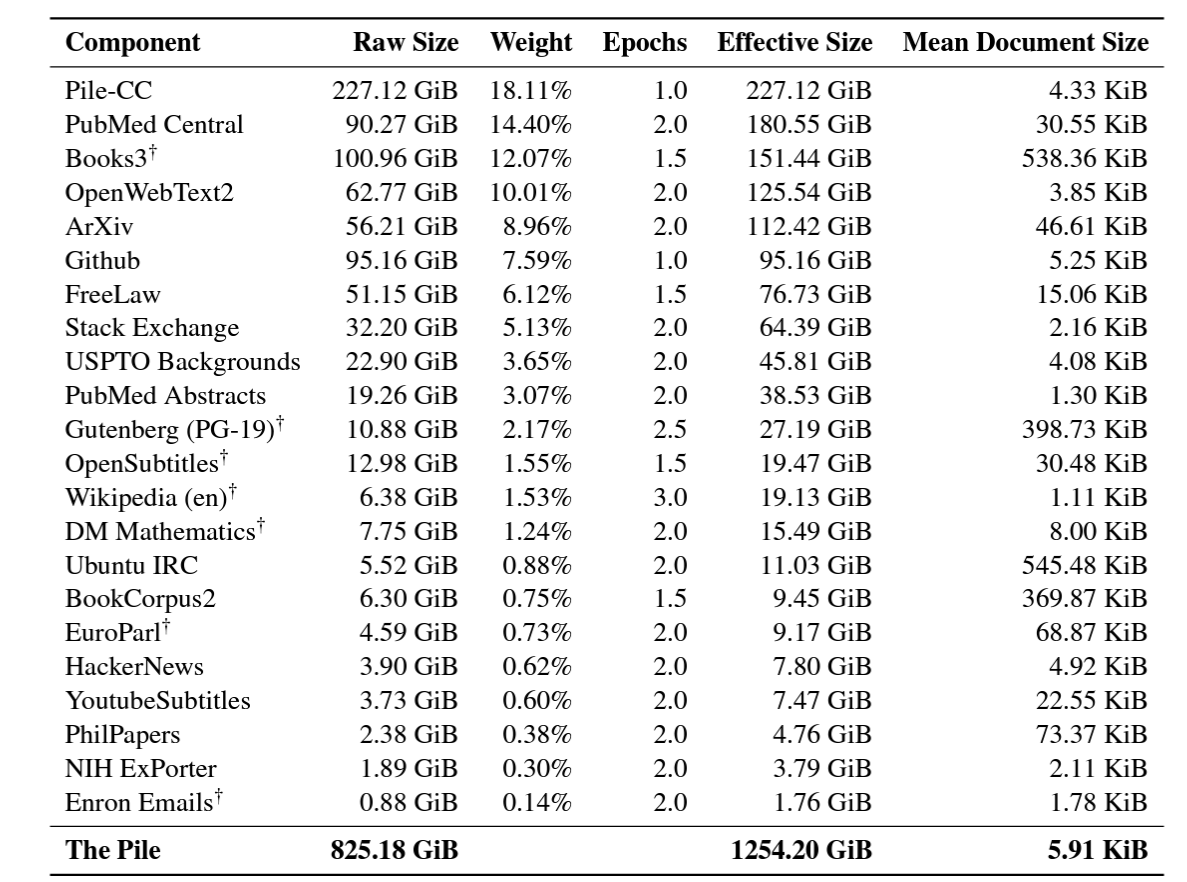

https://arxiv.org/abs/2101.00027

In [90]:
from datasets import get_dataset_config_names

# Get all subsets of The Pile dataset
dataset_name = "EleutherAI/pile"
thepile_subsets = get_dataset_config_names(dataset_name)

# Print all available subsets
print(thepile_subsets)

['all', 'enron_emails', 'europarl', 'free_law', 'hacker_news', 'nih_exporter', 'pubmed', 'pubmed_central', 'ubuntu_irc', 'uspto', 'github']
time: 740 ms (started: 2024-08-23 11:41:07 +00:00)


In [68]:
dataset_name = "EleutherAI/pile"
thepile_subset = load_dataset(dataset_name, 'enron_emails') 
# ['all', 'enron_emails', 'europarl', 'free_law', 'hacker_news', 'nih_exporter', 'pubmed', 'pubmed_central', 'ubuntu_irc', 'uspto', 'github']


time: 749 ms (started: 2024-08-23 10:53:25 +00:00)


In [69]:
thepile_subset

DatasetDict({
    train: Dataset({
        features: ['text', 'meta'],
        num_rows: 517401
    })
})

time: 2.94 ms (started: 2024-08-23 10:53:27 +00:00)


In [85]:
# Print random item from the dataset
print(thepile_subset['train'][random.randint(0,9999)]['text']) # type: ignore

Message-ID: <23659994.1075863597886.JavaMail.evans@thyme>
Date: Mon, 3 Jul 2000 06:36:00 -0700 (PDT)
From: robert.badeer@enron.com
To: mbelden@mediaone.com
Subject: Price Cap Graphs
Mime-Version: 1.0
Content-Type: text/plain; charset=us-ascii
Content-Transfer-Encoding: 7bit
X-From: Robert Badeer
X-To: mbelden@mediaone.com
X-cc: 
X-bcc: 
X-Folder: \Robert_Badeer_Aug2000\Notes Folders\Discussion threads
X-Origin: Badeer-R
X-FileName: rbadeer.nsf

---------------------- Forwarded by Robert Badeer/HOU/ECT on 07/03/2000 01:39 
PM ---------------------------

06/30/2000 05:08 PM
Cooper Richey
Cooper Richey
Cooper Richey
06/30/2000 05:08 PM
06/30/2000 05:08 PM
To: David Parquet/SF/ECT@ECT
cc: Robert Badeer/HOU/ECT@ECT, Tim Belden/HOU/ECT@ECT 
Subject: Price Cap Graphs

Dave,

Here is the next cut,  

I've listed assumptions and added the regulation to the ancillary service 
component







time: 854 µs (started: 2024-08-23 11:03:30 +00:00)


In [81]:
# Number of samples to take
num_samples = 10000

# Subset the dataset
thepile_subset_mini = thepile_subset['train'].select(range(num_samples)) 

time: 4.53 ms (started: 2024-08-23 10:58:16 +00:00)


In [88]:
thepile_subset_mini_custom = CustomDataset(
    thepile_subset_mini['text'],
    tokenizer=llama3_tokenizer,
    max_length= 64)

train_dataloader = DataLoader(thepile_subset_mini_custom, batch_size=4, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(thepile_subset_mini_custom, batch_size=4, collate_fn=collate_fn, shuffle=True)

time: 27.7 ms (started: 2024-08-23 11:04:01 +00:00)


In [89]:
epochs = 20 
lr_train = 5e-5
optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train)

llama_3_losses = train_model(simple_llama3_model,
                             optimizer=AdamW(simple_llama3_model.parameters(),lr=lr_train),
                             epochs=epochs,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader, 
                             patience=2,                                               
                             train_verbose=True, 
                             eval_verbose=True,
                             with_autocast=True #cannot use autocast when the model is quantized
                            ) 

# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 11.55 
# Epoch: 1 (Learning rate: 5e-05)  Training loss: 11.37 || Validation loss: 11.18
# Epoch: 5 (Learning rate: 5e-05)  Training loss: 9.51 || Validation loss: 9.24
# Epoch: 10 (Learning rate: 5e-05)  Training loss: 6.71 || Validation loss: 6.48
# Epoch: 15 (Learning rate: 5e-05)  Training loss: 5.35 || Validation loss: 5.31
# Epoch: 20 (Learning rate: 5e-05)  Training loss: 5.17 || Validation loss: 5.17
time: 37min 5s (started: 2024-08-23 11:04:02 +00:00)


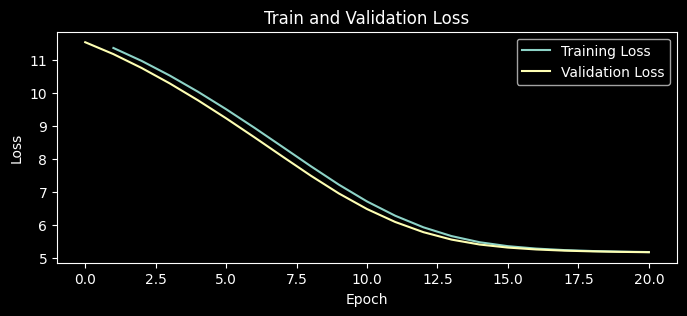

time: 327 ms (started: 2024-08-23 11:52:09 +00:00)


In [92]:
plot_results(llama_3_losses)

##### Create Reference Model

In [ ]:
# Example usage
vocab_size = len(llama3_tokenizer)     #Real   Llama values # Example vocabulary size
embed_dim = 2         #4096   #Real Llama values  # Example embedding dimension
num_heads = 1           #64     # Number of attention heads
num_layers = 1          #60     # Number of transformer layers
ff_hidden_dim = 2     #4096   # Feed-forward hidden dimension

llama3_model = SimpleLlama(vocab_size, embed_dim, num_heads, num_layers, ff_hidden_dim).to(DEVICE)

In [ ]:
reference_model_path = 'C:/Users/user/Desktop/My_Files/Anaconda  Projects/data/Models/llama3_model_reference.pt'

In [ ]:
# # Save the model's state dictionary
torch.save(llama3_model.state_dict(), reference_model_path)

In [ ]:
llama3_model.load_state_dict(torch.load(reference_model_path))

##### Create Scouts and Guidance Matrix

In [ ]:
llama3_scouts = gtl.create_scouts(simple_llama3_model,should_save_guidance=False,should_save_scouts=False,use_squared_differences=True)
print("Scouts created")

- Train Scouts

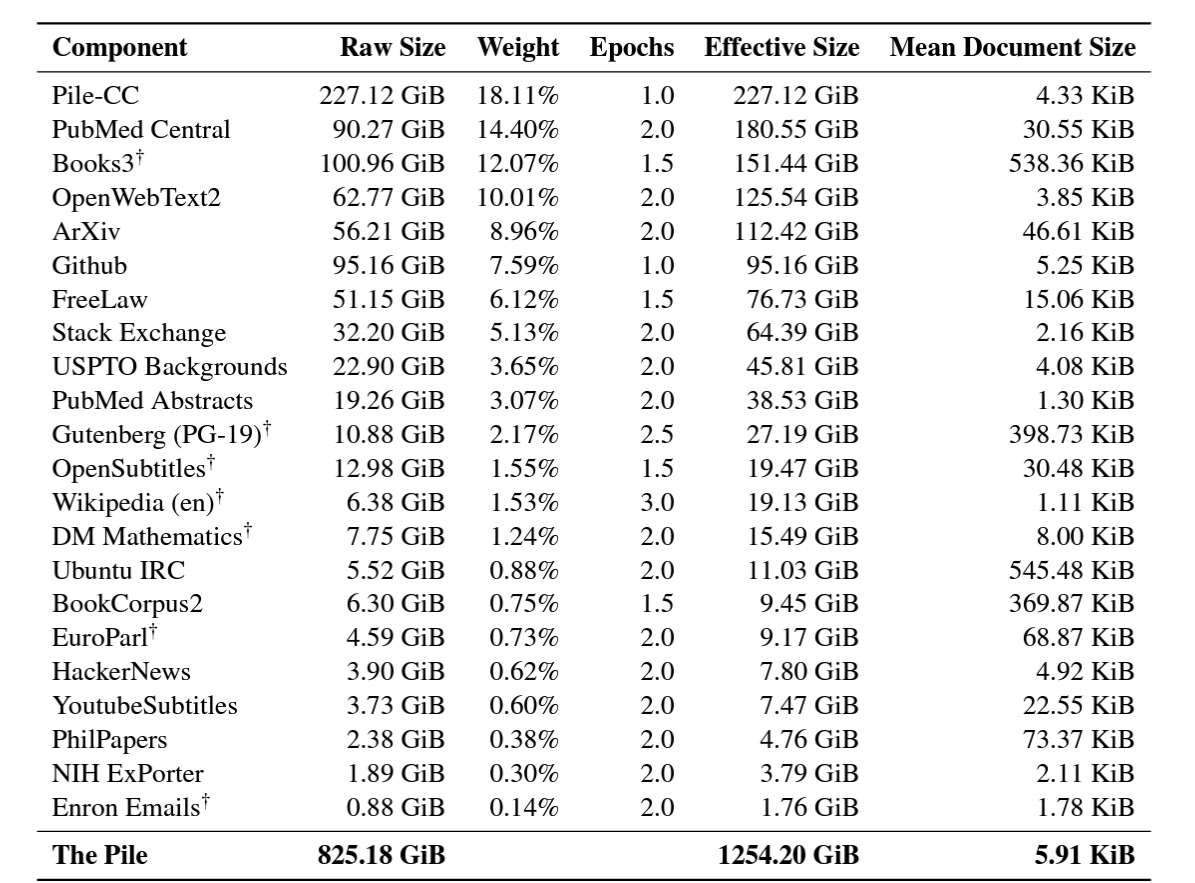

In [132]:
# Since we cannot download subsets of the pile from HG, we can download each subest from a different source directly:

thepile_datasets_links =['jacquelinehe/enron-emails', # 972 MB 
                         'amongglue/youtube_subtitles',  #1.96 GB
                         'jkeisling/hacker-news-corpus-2007-2022',# 2.97 GB
                        ] #'free_law', 'pubmed', 'pubmed_central',  'uspto', 'github']]



time: 649 µs (started: 2024-08-23 14:21:06 +00:00)


Start Training Scouts:

Scout for subset: nih_exporter Training Start:
nih_exporter loaded.
# Llama-3 Reference Model loaded. Starting training model.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 13.25 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 12.79 || Validation loss: 13.30
{'train_results': [[12.793929173396183]], 'validation_results': [[13.247430948110727, 13.296780366163988]]}


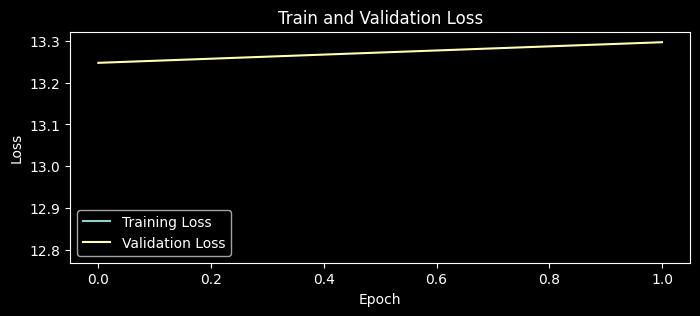


# Scout  nih_exporter Training End.

Scout for subset: nih_exporter Training Start:


Loading dataset shards:   0%|          | 0/17 [00:00<?, ?it/s]

nih_exporter loaded.
# Llama-3 Reference Model loaded. Starting training model.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 14.56 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 14.65 || Validation loss: 14.51
{'train_results': [[14.645638319162222]], 'validation_results': [[14.559183047367977, 14.512970264141376]]}


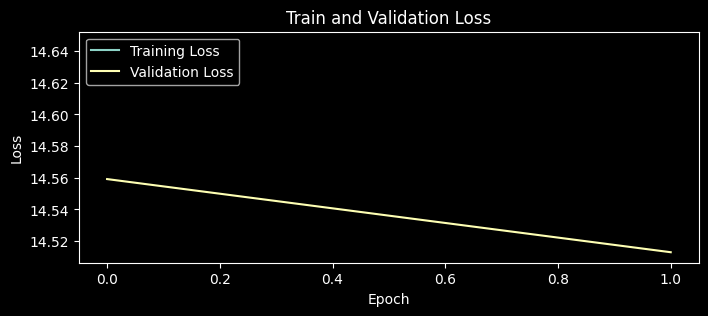


# Scout  nih_exporter Training End.

Scout for subset: nih_exporter Training Start:


Generating train split: 0 examples [00:00, ? examples/s]

nih_exporter loaded.
# Llama-3 Reference Model loaded. Starting training model.
# Epoch: 0  (Before start training) 
# Evaluating on Validation Dateset: # Validation loss: 14.58 
# Epoch: 1 (Learning rate: 2e-05)  Training loss: 14.58 || Validation loss: 14.57
{'train_results': [[14.58497216151311]], 'validation_results': [[14.580512120173527, 14.573713155893179]]}


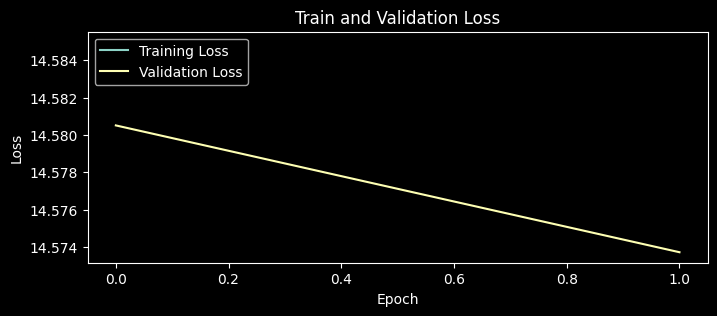


# Scout  nih_exporter Training End.

All Scouts in [ {'jkeisling/hacker-news-corpus-2007-2022', 'jacquelinehe/enron-emails', 'malteos/philpapers-2023-10-28amongglue/youtube_subtitles'} ]  Training End.

time: 5min 38s (started: 2024-08-23 14:21:18 +00:00)


In [135]:
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 3
EPOCHS = 1
PATIENCE = 2
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 32
ITEMS_FROM_SUBEST_NB = 100

assert NB_SCOUTS <= len(thepile_datasets_links), "nb_scouts exceeds the length of the list."

print("Start Training Scouts:\n")
for subset_link in thepile_datasets_links[:NB_SCOUTS]:
    print(f"=============================================================\nScout for subset: {subset} Training Start:") 

    dataset = load_dataset(subset_link, split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 
    print(f"{subset} loaded.")
    
    train_dataset = dataset['train'][:ITEMS_FROM_SUBEST_NB]
    val_dataset = dataset['validation'][:ITEMS_FROM_SUBEST_NB]
    
    thepile_custom_train_subset = CustomDataset(train_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
    thepile_custom_val_subset = CustomDataset(val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

    train_dataloader = DataLoader(thepile_custom_train_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
    val_dataloader = DataLoader(thepile_custom_val_subset, batch_size=BATCH_SIZE, collate_fn=collate_fn, shuffle=True)
        
    # Load reference model:
#     simple_llama3_model.load_state_dict(torch.load(reference_model_path))

    print(f"# Llama-3 Reference Model loaded. Starting training model.") 

    print('================================================================')
    losses = train_model(llama3_model,
                         optimizer=AdamW(llama3_model.parameters(),lr=LEARNING_RATE),
                         epochs=EPOCHS,
                         train_loader=train_dataloader,
                         validation_loader=val_dataloader,
                         train_verbose=True, 
                         eval_verbose=True,
                         with_early_stopping=False,
                         with_autocast=True,
                         with_lr_sceduler=False,                                 
                        )
    print(losses)
    plot_results(losses)

    print(f"\n# Scout  {subset} Training End.\n=============================================================\n")    
    llama3_scouts.add_scout(llama3_model)     
    del dataset
print(f"All Scouts in [ {thepile_datasets_list} ]  Training End.\n=============================================================\n")



In [ ]:
# Create the guidance matrix from the scouts:
llama3_raw_guidance_matrix = llama3_scouts.create_raw_guidance(DEVICE) 


In [ ]:
gtl.save_guidance_matrix(llama3_raw_guidance_matrix, name='llama3_raw_guidance_matrix.pt') 

In [ ]:
gtl.plot_guidance_distribution(llama3_raw_guidance_matrix)

- Rescale Guidance Matrix

In [ ]:
llama3_rescaled_guidance_matrix = llama3_raw_guidance_matrix.copy() 
def rescale_matrix_layer_by_layer(matrix):
    for layer in matrix:
        min_layer = torch.amin(matrix[layer])
        max_layer = torch.amax(matrix[layer])
        scale =  1/(max_layer - min_layer)
        if scale is not torch.inf:
            matrix[layer] = scale *  matrix[layer]
            
rescale_matrix_layer_by_layer(llama3_rescaled_guidance_matrix)
llama3_rescaled_guidance_matrix


##### Train With GTL: Few-Show Learn

In [ ]:
# texts = [
#     "In the serene countryside, the golden rays of the sun danced upon the lush green fields, painting a picturesque scene. The gentle breeze carried the sweet scent of blooming flowers, while birds chirped melodiously, creating a symphony of nature. The tranquil river flowed gracefully, reflecting the clear blue sky. A lone fisherman sat by the riverbank, casting his line with patience, his thoughts drifting like the clouds above. Children played nearby, their laughter echoing through the valley. It was a perfect day, where time seemed to stand still in nature's embrace.",
#     "On a bustling city street, cars honked and people rushed by, each engrossed in their own world. The towering skyscrapers cast long shadows on the pavement below, where vendors sold their wares to passersby. A street musician played a soulful tune on his guitar, his music weaving through the noise of the city. A group of friends gathered at a nearby café, sharing stories and laughter over cups of steaming coffee. Despite the chaos, there was a sense of community, of lives intersecting in this vibrant urban jungle, each with a story to tell.",
#     "In a quiet library, the scent of old books filled the air, and the only sounds were the soft rustling of pages and the occasional whisper. Sunlight streamed through tall windows, casting a warm glow on the rows of bookshelves that lined the walls. A young student sat at a wooden table, deeply engrossed in a thick novel, his eyes scanning the pages with curiosity. Nearby, an elderly man browsed the history section, his fingers tracing the spines of ancient tomes. It was a sanctuary of knowledge, where time slowed down and minds could wander freely.",
#     "At the edge of a dense forest, a small cabin stood nestled among the trees, its wooden walls weathered by years of enduring the elements. Smoke curled lazily from the chimney, hinting at the warmth within. Inside, a fire crackled in the hearth, casting flickering shadows on the walls. A woman sat by the window, knitting a woolen scarf, her mind wandering to distant memories. Outside, a deer grazed near the treeline, its ears twitching at the slightest sound. The world seemed distant here, where nature's embrace offered solace and a connection to the earth.",
#    ]


In [ ]:
# Empty GPU cache
torch.cuda.empty_cache()

In [ ]:
##  Take one or more  items fron wikitext for Few-shot learn:
NUM_SAMPLES = 1
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 3
EPOCHS = 1
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 32
ITEMS_FROM_SUBEST_NB = 100


dataset = load_dataset("wikitext", subset, split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 

wikitext_train_dataset = dataset['train'][:NUM_SAMPLES]
wikitext_val_dataset = dataset['validation'][:NUM_SAMPLES]

wikitext_custom_dataset = CustomDataset(wikitext_train_dataset['text'], tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
wikitext_val_dataset = CustomDataset(wikitext_val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

# Create DataLoaders
train_dataloader = DataLoader(wikitext_custom_dataset, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(wikitext_val_dataset, batch_size=batch_size,collate_fn=collate_fn, shuffle=True)

# Load reference model:
llama3_model.load_state_dict(torch.load(reference_model_path))

print(f"# Llama-3 Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.") 
# train model (not intersted in results: _)
optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier)
print('================================================================')

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=learning_rate),
                             epochs=EPOCHS,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=True,
                             guidance_matrix=llama3_rescaled_guidance_matrix,
                             with_autocast=True,
                             with_lr_sceduler=False
                             )

print(llama_3_losses) 
plot_results(llama_3_losses) 

##### Train Without GTL: Few-Shot Learn


In [ ]:
# Empty GPU cache
torch.cuda.empty_cache()

In [ ]:
##  Take one or more  items fron wikitext for Few-shot learn:
NUM_SAMPLES = 1
# num_labels = 10 #already defined in whe crating reference BERT_Classification_model
NB_SCOUTS = 3
EPOCHS = 1
BATCH_SIZE = 8
LOSS_FUNCTION = nn.CrossEntropyLoss()  # Combines the softmax activation function and the negative log-likelihood loss in a single operation
LEARNING_RATE = 2e-5
MAX_LENGTH = 32
ITEMS_FROM_SUBEST_NB = 100


dataset = load_dataset("wikitext", subset, split={'train': 'train[:80%]', 'validation': 'train[80%:]'}) 

wikitext_train_dataset = dataset['train'][:NUM_SAMPLES]
wikitext_val_dataset = dataset['validation'][:NUM_SAMPLES]

wikitext_custom_dataset = CustomDataset(wikitext_train_dataset['text'], tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )
wikitext_val_dataset = CustomDataset(wikitext_val_dataset['text'],tokenizer=llama3_tokenizer,max_length=MAX_LENGTH )

# Create DataLoaders
train_dataloader = DataLoader(wikitext_custom_dataset, batch_size=batch_size, collate_fn=collate_fn, shuffle=True)
val_dataloader = DataLoader(wikitext_val_dataset, batch_size=batch_size,collate_fn=collate_fn, shuffle=True)

# Load reference model:
llama3_model.load_state_dict(torch.load(reference_model_path))

print(f"# Llama-3 Reference Model loaded. Starting training model with {nb_of_layers_to_unfreeze} layer(s) unfrozen.") 
# train model (not intersted in results: _)
optimizer=AdamW(llama3_model.parameters(),lr=lr_train_classifier)
print('================================================================')

llama_3_losses = train_model(llama3_model,
                             optimizer=AdamW(llama3_model.parameters(),lr=learning_rate),
                             epochs=EPOCHS,
                             train_loader=train_dataloader,
                             validation_loader=val_dataloader,
                             train_verbose=True, 
                             eval_verbose=True,
                             with_GTL=False,
                             with_autocast=True,
                             with_lr_sceduler=False
                             )

print(llama_3_losses) 
plot_results(llama_3_losses) 